### Ejercicio 1. Representa, la siguiente curva:
$$\beta(t)=\bigg(\cos\left(\frac{t}{\sqrt{2}}\right),\sin\left(\frac{t}{\sqrt{2}}\right), \frac{t}{\sqrt{2}}\bigg), \quad t\in (0 \leq t \leq 4\pi)$$
### usando numpy y haciendo una partición de 250 puntos en el intervalo dado.



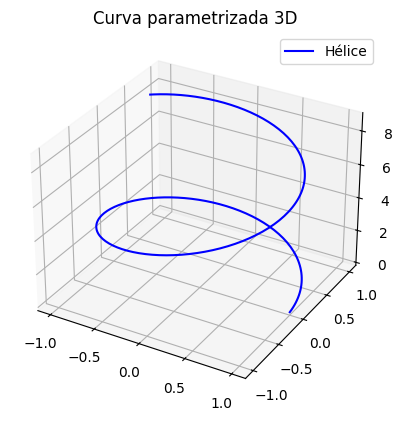

In [ ]:
import numpy as np  # Importamos NumPy para operaciones numéricas
import matplotlib.pyplot as plt  # Importamos Matplotlib para visualización
from mpl_toolkits.mplot3d import Axes3D  # Importamos la herramienta para gráficos 3D

PUNTOS = 250 #Constante numero de puntos para el intervalo

t = np.linspace(0, 4*np.pi, PUNTOS) #Defino intervalo de 250 puntos
x = np.cos(t/np.sqrt(2))
y = np.sin(t/np.sqrt(2))
z = t/np.sqrt(2)

#Grafica -------------------------------------------
fig = plt.figure() #Abro figura
ax = fig.add_subplot(111, projection = '3d')
ax.plot(x,y,z, label = 'Hélice', color = 'b')

ax.set_xlabel = 'Eje X'
ax.set_ylabel = 'Eje Y'
ax.set_zlabel = 'Eje Z'
plt.title('Curva parametrizada 3D')
ax.grid(True) #Activa rejilla
ax.legend()
plt.show()


### Ejercicio 2. Calcula usando Sympy el Tiedro de Frenet, curvatura y torsión de la curva del ejercicio anterior.

In [ ]:
import sympy as sp

t = sp.Symbol('t') #Declaro variable simbólica

# Vector de componentes de la curva
x = sp.cos(t/np.sqrt(2)) # componente x
y = sp.sin(t/np.sqrt(2)) # componente y
z = t/np.sqrt(2) # componente z
alpha = sp.Matrix([x,y,z]) #vector que describe la curva

# Derivadas
primeraDeriv = alpha.diff(t) # Primera derivada respecto t
segundaDeriv = primeraDeriv.diff(t) # Segunda derivada respecto t
terceraDeriv = segundaDeriv.diff(t) # Tercera derivada respecto t

# Producto cruz Primera y segunda derivada y su norma
productoCruz12 = primeraDeriv.cross(segundaDeriv)
normaProductoCruz12 = sp.sqrt(sum(productoCruz12[i]**2 for i in range(3)))
normaPrimeraDeriv = sp.sqrt(sum(primeraDeriv[i]**2 for i in range(3)))
normaSegundaDeriv = sp.sqrt(sum(segundaDeriv[i]**2 for i in range(3)))

# Triedro de Frenet
T = primeraDeriv / normaSegundaDeriv # Vector tangente unitario
B = productoCruz12 / normaProductoCruz12 # Vector binormal unitario
N = B.cross(T) #Vector normal unitario

#Curvatura
K = normaProductoCruz12 / normaPrimeraDeriv**3

# Torsion
T = productoCruz12.dot(terceraDeriv) / normaProductoCruz12**2

# Mostrar resultados triedro
print("Triedro: \n")
print("T = ")
display (sp.simplify(T))
print("\nB = ")
display(sp.simplify(B))
print ("\nN = ")
display(sp.simplify(N))
print ("\n")
# Mostrar resultados curvatura y torsion
print ("\n Curvatura y torsion: ")
print("\nK = ")
display(sp.simplify(K))
print("\nT = ")
display(sp.simplify(T))








Triedro: 

T = 


0.500000000000000


B = 


Matrix([
[ 0.5*sqrt(2)*sin(0.707106781186547*t)],
[-0.5*sqrt(2)*cos(0.707106781186547*t)],
[                          0.5*sqrt(2)]])


N = 


Matrix([
[-1.4142135623731*sqrt(2)*cos(0.707106781186547*t)],
[-1.4142135623731*sqrt(2)*sin(0.707106781186547*t)],
[                                                0]])




 Curvatura y torsion: 

K = 


0.500000000000000


T = 


0.500000000000000

### Ejercicio 3. Representa usando Sympy la superficie dada por:
$$z=sin(x+y)$$
en el dominio:
$$D=\{(x,y)\in \mathbb{R}^2 | \ \  x\in[-2\pi, 2\pi], \ \ y\in [-2\pi, 2\pi]\}.$$

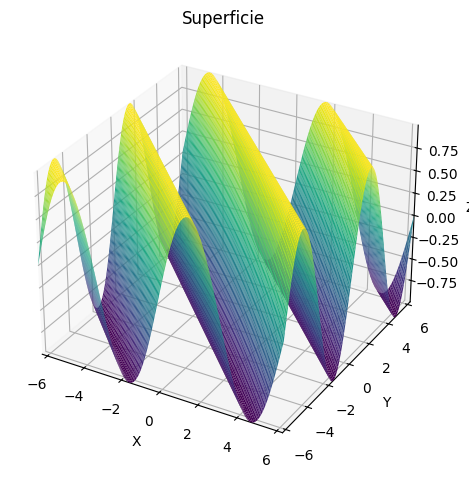

In [ ]:
import sympy as sp
from sympy.plotting import plot3d_parametric_surface

# Variables simbólicas
x,y = sp.symbols('x y')

#Graficar
plot3d_parametric_surface(x, y, sp.sin(x+y),
                          (x, -2*sp.pi, 2*sp.pi),(y, -2*sp.pi, 2*sp.pi),
                          title = 'Superficie',
                          xlabel = 'X', ylabel = 'Y', zlabel = 'Z')


### Ejercicio 4. Usando Sympy calcula los coeficientes de la Primera y Segunda Forma Fundamental, así como la superficie de Gauss y media en el punto (1,1,0) de la superficie parametrizada por
$$\Phi(u,v) = (u^2\cos(v), u^2-v^2, uv)$$

In [ ]:
import sympy as sp

u, v = sp.symbols('u v') # Variables simbólicas
P = [1, 1, 0] # Punto P

#Resolver que u y v para que satisfagan las componentes del punto -------------
x_comp = u**2 * sp.cos(v)
y_comp = u**2 - v**2
z_comp = u*v
phi = sp.Matrix([x_comp, y_comp, z_comp]) #funcion superficie parametrizada

#Componentes igualadas a la componente del punto
eq1 = sp.Eq(x_comp,P[0])
eq2 = sp.Eq(y_comp,P[1])
eq3 = sp.Eq(z_comp,P[2])

solucion = sp.solve([eq1, eq2, eq3],[u, v])
display(solucion) # Se obtienen dos soluciones escogeré la positiva

u_val = solucion[1][0] #Obtengo la segunda tupla, primera componente
v_val = solucion[1][1] #Obtengo la segunda tupla, segunda componente
#------------------------------------------------------------------------------

#Derivadas
derivRespectU = phi.diff(u) #Derivada parcial respecto de u
derivRespectV = phi.diff(v)  #Derivada parcial respecto de v

segDerivRespectU = derivRespectU.diff(u)
segDerivRespectV = derivRespectV.diff(v)
derivMixta = derivRespectU.diff(v)

#Coeficientes de la primera forma fundamental.
E = derivRespectU.dot(derivRespectU)
F = derivRespectU.dot(derivRespectV)
G = derivRespectV.dot(derivRespectV)

#Vector normal unitario
prodCruzParciales = derivRespectU.cross(derivRespectV)
normaProdCruzParciales = sp.sqrt(prodCruzParciales.dot(prodCruzParciales))
nUnitario = prodCruzParciales / normaProdCruzParciales

#Coeficientes segunda forma fundamental
e = segDerivRespectU.dot(nUnitario)
f = derivMixta.dot(nUnitario)
g = segDerivRespectV.dot(nUnitario)

#Curvatura de Gauss
K = sp.simplify((e*g - f**2) / (E*G - F**2))

#Curvatura media
M = sp.simplify((E*g - 2*F*f + G*e) / (2*(E*G - F**2)))

#Angulo entre curvas coordenadas
theta = sp.acos(F/sp.sqrt(E*G))

#Evaluar en P(1,1,0) con valores de (u,v)
subs_dict = {u:u_val , v:v_val}

E_val = E.subs(subs_dict).evalf()
F_val = F.subs(subs_dict).evalf()
G_val = G.subs(subs_dict).evalf()

e_val = e.subs(subs_dict).evalf()
f_val = f.subs(subs_dict).evalf()
g_val = g.subs(subs_dict).evalf()

K_val = K.subs(subs_dict).evalf()
M_val = M.subs(subs_dict).evalf()

print(f"E = {E_val}")
print(f"F = {F_val}")
print(f"G = {G_val}")
print(f"e = {e_val}")
print(f"f = {f_val}")
print(f"g = {g_val}")
print(f"Curvatura de Gauss K = {K_val}")
print(f"Curvatura media H = {M_val}")

[(-1, 0), (1, 0)]

E = 8.00000000000000
F = 0
G = 1.00000000000000
e = 0
f = 0
g = 0.707106781186548
Curvatura de Gauss K = 0
Curvatura media H = 0.353553390593274


### Ejercicio 5. Usando Sympy Calcular la integral de línea de la curva parametrizada $\vec\alpha(t)=(2\cos(t),2\sin(t), t)$ con $t\in [0,\pi]$ sobre el campo escalar $f(x,y)=x+y$.

In [ ]:
import sympy as sp

t = sp.symbols('t')

#Curva parametrizada
alpha = sp.Matrix([2*sp.cos(t), 2*sp.sin(t), t])

#Funcion Campo escalar (f(x,y,z))
def f(v):
  x, y, z = v
  return x+y #Devuelve la funcion campo escalar

#Evaluar
f_alpha = f(alpha)

#Velocidad y su norma
primeraDerivada = alpha.diff(t)
normaPrimeraDeriv = sp.sqrt(primeraDerivada.dot(primeraDerivada))

#Integrar
integralLinea = sp.integrate(f_alpha * normaPrimeraDeriv,(t, 0, sp.pi))

print(sp.simplify(integralLinea))



4*sqrt(5)
